In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Mean: -0.012734227054626537


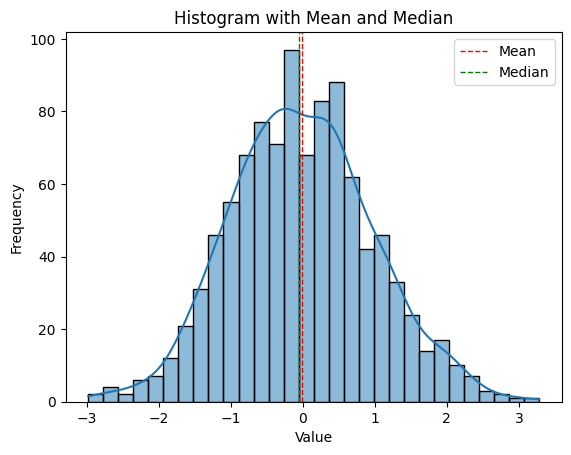

In [2]:
# lets generate some random data
data = np.random.randn(1000)
# Calculate basic statistics
mean = np.mean(data)
print("Mean:", mean)
median = np.median(data)
std_dev = np.std(data)
# histogram along with mean and median lines
sns.histplot(data, bins=30, kde=True)
plt.axvline(mean, color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(median, color='green', linestyle='dashed', linewidth=1, label='Median')
plt.title('Histogram with Mean and Median')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


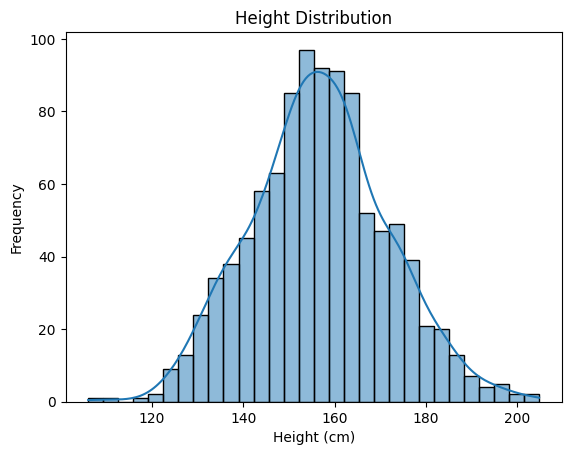

Mean Height: 156.70292252481454
Standard Deviation of Height: 14.934646688251158


In [3]:
# lets create a random --> normally distributed dataset
height = np.random.normal(loc=156, scale=15, size=1000)
# here loc is the mean and scale is the standard deviation
sns.histplot(height, bins=30, kde=True)
plt.title('Height Distribution')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.show()
# Calculate and print mean and standard deviation
mean_height = np.mean(height)
std_dev_height = np.std(height)
print("Mean Height:", mean_height)
print("Standard Deviation of Height:", std_dev_height)

Outlier Transactions: [299.37995379 298.85085367 294.08589637 309.33451805 290.52911781
 298.05157787 300.78494629 305.9527851  302.59534667 297.11157966]


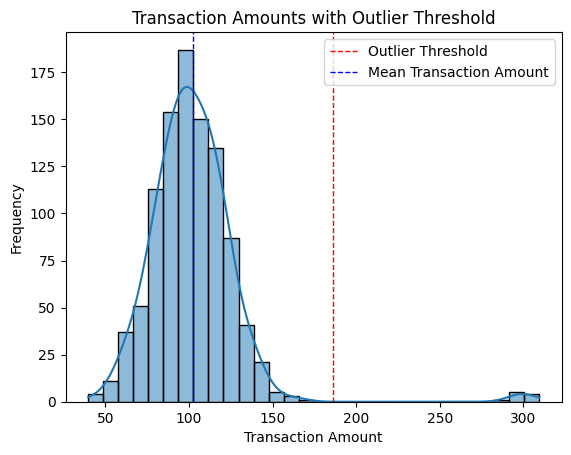

In [4]:
# lets create some trasaction data with outliers to explain fraud detection 
transactions = np.random.normal(loc=100, scale=20, size=1000)
# Adding some outliers
outliers = np.random.normal(loc=300, scale=10, size=10)
transactions = np.concatenate((transactions, outliers))

# if any transaction is greater than mean + 3*std_dev, we will consider it as an outlier
mean_trans = np.mean(transactions)
std_dev_trans = np.std(transactions)
threshold = mean_trans + 3 * std_dev_trans
outlier_transactions = transactions[transactions > threshold]
print("Outlier Transactions:", outlier_transactions)

# lets plot the transactions with outliers highlighted
sns.histplot(transactions, bins=30, kde=True)
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=1, label='Outlier Threshold')
# add mean line
plt.axvline(mean_trans, color='blue', linestyle='dashed', linewidth=1, label='Mean Transaction Amount')
plt.title('Transaction Amounts with Outlier Threshold')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

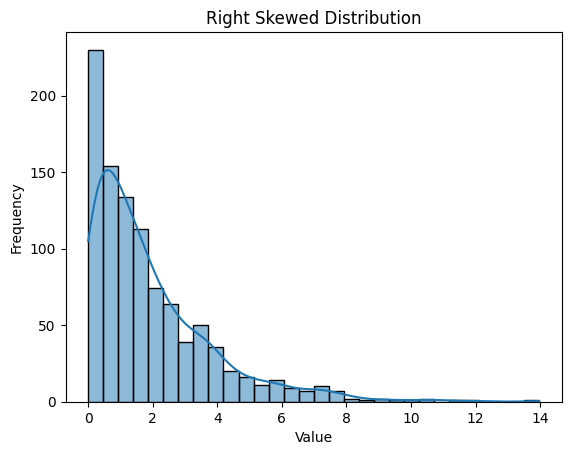

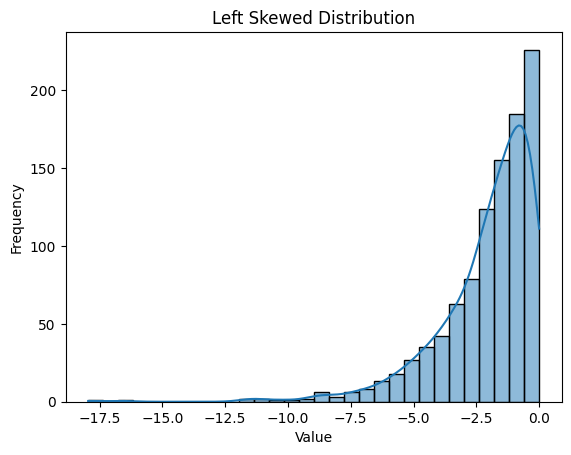

In [5]:
# skewness
data = np.random.exponential(scale=2, size=1000) # right skewed data
sns.histplot(data, bins=30, kde=True)
plt.title('Right Skewed Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# left skewed data
data_left = -np.random.exponential(scale=2, size=1000)
sns.histplot(data_left, bins=30, kde=True)
plt.title('Left Skewed Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# what is the use of skewness
# In finance, skewness helps in assessing the risk of investment returns.
#  A right-skewed distribution may indicate a higher probability of extreme positive returns, 
# while a left-skewed distribution may indicate a higher probability of extreme negative returns.


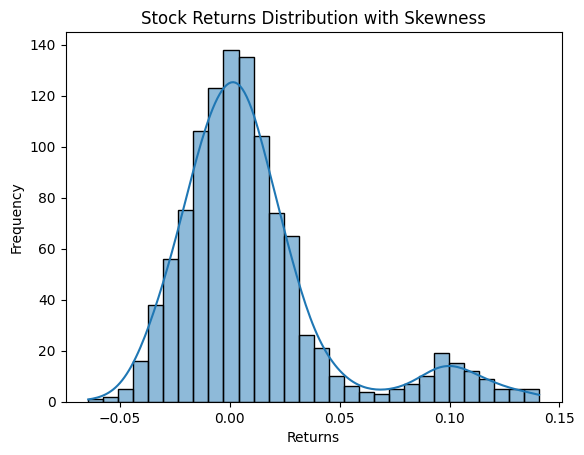

In [6]:
# lets take one stoc data to understanf the skewness
# Generating synthetic stock return data
stock_returns = np.random.normal(loc=0.001, scale=0.02, size=1000)
# Introduce skewness
stock_returns = np.concatenate((stock_returns, np.random.normal(loc=0.1, scale=0.02, size=100)))
sns.histplot(stock_returns, bins=30, kde=True)
plt.title('Stock Returns Distribution with Skewness')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()

# here we can see that the stock returns are 
# right skewed, indicating a higher probability of extreme positive returns.

# This information can be useful for investors
# in making decisions about risk management and portfolio allocation.


In [7]:
# you can caclculate skewness using scipy
from scipy.stats import skew
skewness_value = skew(stock_returns)
print("Skewness of Stock Returns:", skewness_value)

# how to interpret skewness value
# A skewness value greater than 0 indicates a right-skewed distribution,
# while a value less than 0 indicates a left-skewed distribution.
# A value close to 0 suggests a symmetric distribution.

# for eg if you are getting very high positive skewness for stock returns
# it indicates that there are potential for extreme positive returns
# but it also means that the majority of returns are concentrated on the lower side
# which can be risky for investors.


Skewness of Stock Returns: 1.570232430981561


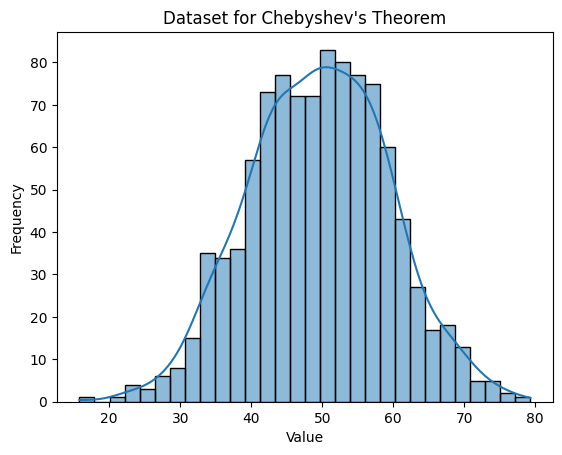

In [8]:
# chebyshev's Theorem
# lets create a random dataset
data_cheb = np.random.randn(1000) * 10 + 50  # mean=50, std_dev=10
mean_cheb = np.mean(data_cheb)
std_dev_cheb = np.std(data_cheb)

# plot the data
sns.histplot(data_cheb, bins=30, kde=True)
plt.title('Dataset for Chebyshev\'s Theorem')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [9]:
# how many people are there between 20 and 30 using chebyshev's theorem
k1 = (mean_cheb - 20) / std_dev_cheb
k2 = (30 - mean_cheb) / std_dev_cheb
k = min(k1, k2)
proportion = 1 - (1 / k**2)
print(f"At least {proportion*100:.2f}% of data lies between 20 and 30.")

At least 74.79% of data lies between 20 and 30.


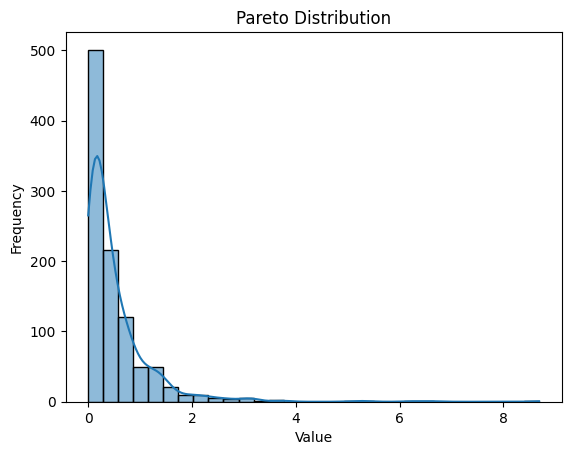

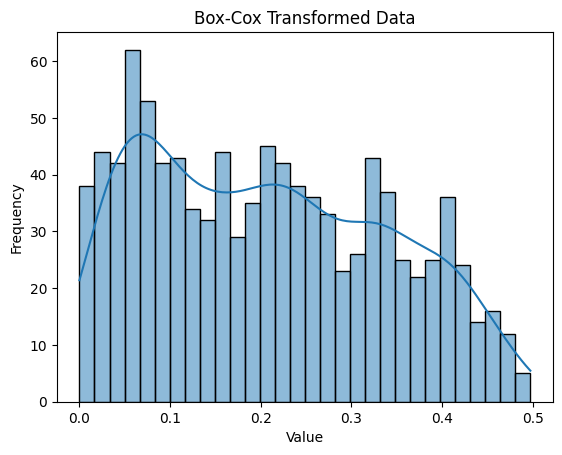

Fitted Lambda for Box-Cox Transformation: -1.9886218752722293


In [10]:
# lets create pareto distribution to explain 80-20 rule
data_pareto = np.random.pareto(a=3, size=1000)
sns.histplot(data_pareto, bins=30, kde=True)
plt.title('Pareto Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


# I will use - > box cox transformation to make the data normal
from scipy.stats import boxcox

boxcox_data, fitted_lambda = boxcox(data_pareto + 1)  # adding 1 to avoid zero values
sns.histplot(boxcox_data, bins=30, kde=True)
plt.title('Box-Cox Transformed Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()
print("Fitted Lambda for Box-Cox Transformation:", fitted_lambda)

# why box cox transformation is useful
# Box-Cox transformation is useful because it helps
# to stabilize variance and make the data more normally distributed.
# This is particularly important for statistical analyses


In [11]:
# lets create two variable height and weight to explain correlation
height = np.random.normal(loc=170, scale=10, size=1000)
weight = height * 0.5 + np.random.normal(loc=0, scale=5, size=1000)  # weight correlated with height

# co-variance
covariance = np.cov(height, weight)[0][1]   
print("Covariance between Height and Weight:", covariance)

Covariance between Height and Weight: 51.90972584576368


Pearson Correlation Coefficient between Height and Weight: 0.7194822247096649
There is a positive correlation between Height and Weight.


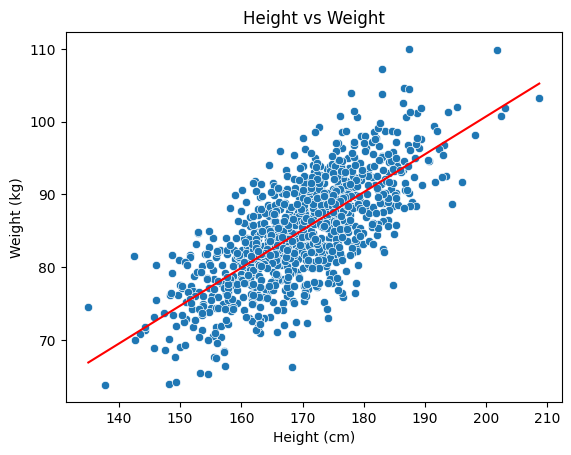

In [16]:
# person correlation coefficient using formula
std_dev_height = np.std(height)
std_dev_weight = np.std(weight)
correlation_coefficient = covariance / (std_dev_height * std_dev_weight)
print("Pearson Correlation Coefficient between Height and Weight:", correlation_coefficient)

# establish the relationship 
if correlation_coefficient > 0:
    print("There is a positive correlation between Height and Weight.")
elif correlation_coefficient < 0:
    print("There is a negative correlation between Height and Weight.")

# visualize the correlation
sns.scatterplot(x=height, y=weight)
plt.plot(np.unique(height), 
         np.poly1d(np.polyfit(height, weight, 1))(np.unique(height)), 
         color='red', label='Trend Line')
plt.title('Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

# conclusion
# A positive correlation indicates that as height increases, weight tends to increase as well.
# This relationship can be useful in various applications, such as health assessments and fitness planning.

In [ ]:
# spearman correlation
# lets prepare the data
height_rank = pd.Series(height).rank()
weight_rank = pd.Series(weight).rank()

# spearman correlation
d = pd.DataFrame({'height': height_rank, 'weight': weight_rank})
spearman_corr = d.corr(method='spearman').iloc[0, 1]
print("Spearman Correlation Coefficient between Height and Weight:", spearman_corr)

if spearman_corr > 0:
    print("There is a positive Spearman correlation between Height and Weight.")
elif spearman_corr < 0:
    print("There is a negative Spearman correlation between Height and Weight.")

#conclusion: 
# covariance vs person correlation vs spearman correlation
# Covariance measures the directional relationship between two variables but is not standardized.
# Pearson correlation coefficient standardizes covariance, providing a measure of linear relationship strength.
# Spearman correlation assesses monotonic relationships using ranked data, making it
#  suitable for non-linear associations
# In our height and weight example, all three measures indicate a positive relationship,
#  but Pearson and Spearman correlations provide more interpretable metrics of association strength.



Spearman Correlation Coefficient between Height and Weight: 0.7017393657393658
There is a positive Spearman correlation between Height and Weight.


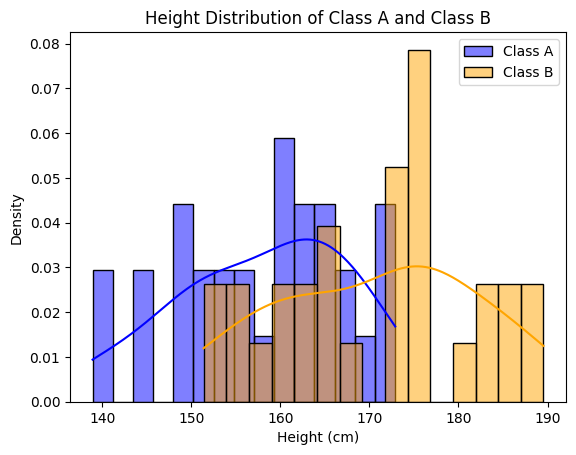

T-statistic: -6.121878283148683
P-value: 9.574865766173817e-09
Reject null hypothesis: Treatment A is significantly better than Treatment B


In [22]:
class_a_height = np.random.normal(loc=160, scale=8, size=30)
class_b_height = np.random.normal(loc=170, scale=10, size=30)

# plot it 
sns.histplot(class_a_height, color='blue', label='Class A', kde=True, stat="density", bins=15)
sns.histplot(class_b_height, color='orange', label='Class B', kde=True, stat="density", bins=15)
plt.title('Height Distribution of Class A and Class B')
plt.xlabel('Height (cm)')
plt.ylabel('Density')
plt.legend()
plt.show()



# why we need hypothesis testing
# Hypothesis testing is essential in statistics as it provides a systematic method to make inferences about
# populations based on sample data. It helps determine whether observed effects or differences are statistically
# significant or likely due to random chance. This is crucial for validating research findings, guiding decision-making,
# and ensuring that conclusions drawn from data are reliable and scientifically sound.



# Example : 
# lets there two medical treatments A and B
# A is claiming to be better than B
# ie if you take treatment A, your recovery time will be less than treatment B
# we will use hypothesis testing to validate this claim

treatment_A = np.random.normal(loc=10, scale=2, size=50)  # mean recovery time 10 days
treatment_B = np.random.normal(loc=12, scale=2.5, size=50)  # mean recovery time 12 days

# null hypothesis: There is no difference in recovery times between treatment A and B
# alternative hypothesis: Treatment A has a lower recovery time than treatment B
from scipy.stats import ttest_ind # here we will use t-test for independent samples
t_stat, p_value = ttest_ind(treatment_A, treatment_B, alternative='less')
alpha = 0.05  # significance level
print("T-statistic:", t_stat) # here t-statistic is negative because we are testing for less than
print("P-value:", p_value)
if p_value < alpha:
    print("Reject null hypothesis: Treatment A is significantly better than Treatment B")
else:
    print("Fail to reject null hypothesis: No significant difference between treatments")

In [ ]:
# Real world application of hypothesis testing
# In clinical trials, hypothesis testing is used to determine the efficacy of new medications or treatments.
# Retail companies use hypothesis testing to evaluate the effectiveness of marketing campaigns by comparing sales data before and after the campaign launch.
# In manufacturing, hypothesis testing helps in quality control by assessing whether a production 
# process meets specified standards

In [25]:
# if you have categorical data, you can use chi-square test for hypothesis testing
# Example:
# lets say we have two groups of people, smokers and non-smokers
# we want to test if there is an association between smoking status and incidence of lung disease
smoking_status = ['smoker', 'non-smoker', 'smoker', 'non-smoker', 'smoker', 'non-smoker']
lung_disease = ['yes', 'no', 'yes', 'no', 'yes', 'no']
data = pd.DataFrame({'smoking_status': smoking_status, 'lung_disease': lung_disease})
contingency_table = pd.crosstab(data['smoking_status'], data['lung_disease'])

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)
# here chi2 is the chi-square statistic, p is the p-value, 
# dof is degrees of freedom, expected is the expected frequencies
# in simple term defgree of freedom is number of categories - 1
# in your case it is 2-1 = 1
alpha = 0.05
print("Chi-square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:\n", expected)
if p < alpha:
    print("Reject null hypothesis: There is an association between smoking status and lung disease")
else:
    print("Fail to reject null hypothesis: No association between smoking status and lung disease")

Chi-square Statistic: 2.6666666666666665
P-value: 0.10247043485974996
Degrees of Freedom: 1
Expected Frequencies:
 [[1.5 1.5]
 [1.5 1.5]]
Fail to reject null hypothesis: No association between smoking status and lung disease


In [ ]:
# ANOVA (Analysis of Variance)
# Example:
# lets say we have three different teaching methods
# we want to test if there is a significant difference in test scores among the three methods
method_1_scores = np.random.normal(loc=75, scale=5, size=30)
method_2_scores = np.random.normal(loc=80, scale=6, size=30)
method_3_scores = np.random.normal(loc=78, scale=4, size=30)
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(method_1_scores, method_2_scores, method_3_scores)
# here f_oneway means one-way ANOVA
alpha = 0.05
print("F-statistic:", f_stat)
print("P-value:", p_value)
if p_value < alpha:
    print("Reject null hypothesis: At least one teaching method is significantly different")
else:
    print("Fail to reject null hypothesis: No significant difference among teaching methods")

F-statistic: 14.711029598233846
P-value: 3.1372776806076398e-06
Reject null hypothesis: At least one teaching method is significantly different


In [ ]:
# Type I and Type II errors
# Type I Error: Rejecting the null hypothesis when it is actually true (false positive).
# Type II Error: Failing to reject the null hypothesis when it is actually false (false negative).

## Reference
 - https://www.investopedia.com/terms/s/skewness.asp
 - https://www.datacamp.com/tutorial/hypothesis-testing
 - https://medium.com/learning-data/how-hypothesis-testing-works-4ecda793d3e8